In [4]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn import linear_model

Functie utilitara pentru a extrage dintr-un fisier csv valorile pentru un numar variabil de atribute de input si valorile pentru variabila de output

In [5]:
def readCSV(filePath, inputVar, outputVar):
    data = []
    dataLabels = []
    line_count = 0
    with open(filePath) as file:
        for line in file.readlines():
            if line_count == 0:
                dataLabels.extend(line.strip().split(","))
            else:
                data.append(line.replace("., ", " ").replace(",,", ",0,").strip().split(","))
            line_count += 1


    outputData = [float(line[dataLabels.index(outputVar)]) for line in data]

    inputData = []
    for iVar in inputVar:
        inputVarIdx = dataLabels.index(iVar)
        inputData.append([float(line[inputVarIdx]) for line in data])
        #plotDataHistogram(inputData[-1], iVar)
        #checkLinearity(inputData[-1], iVar, outputData, outputVar)

    return inputData, inputVar, outputData, outputVar

Functii utilitare pentru randare de grafice

In [6]:
def plotData(x1, y1, x2 = None, y2 = None, x3 = None, y3 = None, title = None):
    plt.plot(x1, y1, 'ro', label = 'train data')
    if x2 is not None:
        plt.plot(x2, y2, 'b-', label = 'learnt model')
    if x3 is not None:
        plt.plot(x3, y3, 'g^', label = 'test data')
    plt.title(title)
    plt.legend()
    plt.show()

def plotData3D(x1_points, x2_points, y_points, x1, x2, y, x1Label = None, x2Label = None, yLabel = None, title1 = None, title2 = None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x1_points, x2_points, y_points, color='blue', label = title1)
    ax.plot_surface(x1, x2, y, alpha=0.3, label = title2)
    ax.set_xlabel(x1Label)
    ax.set_ylabel(x2Label)
    ax.set_zlabel(yLabel)
    ax.legend()
    plt.show()

def plotDataHistogram(inputData, inputLabel):
    plt.hist(inputData, 10)
    plt.title("Histogram of " + inputLabel)
    plt.show()

def checkLinearity(inputData, inputLabel, outputData, outputLabel):
    plt.plot(inputData, outputData, 'ro')
    plt.xlabel(inputLabel)
    plt.ylabel(outputLabel)
    plt.title(inputLabel + " vs. " + outputLabel)
    plt.show()

Functie care imparte datele in date de antrenament si date de validare functionala pe numar variabil de atribute de input.

In [7]:
def splitData(inputData, inputLabel, outputData):
    indexes = [i for i in range(len(inputData[0][:]))]
    trainSample = np.random.choice(indexes, int(0.8*len(inputData[0])), replace=False).tolist()
    testSample = [i for i in indexes if not i in trainSample]
    trainInputs = []
    testInputs = []
    trainOutputs = [outputData[i] for i in trainSample]
    testOutputs = [outputData[i] for i in testSample]

    for idx, data in enumerate(inputData):
        trainInputs.append([data[i] for i in trainSample])
        testInputs.append([data[i] for i in testSample])
        #plotData(trainInputs[-1], trainOutputs, [], [], testInputs[-1], testOutputs, title=f'{inputLabel[idx]} train and test data')

    return trainInputs, testInputs, trainOutputs, testOutputs


In [8]:
def univariateRegression(trainInputs, testInputs, trainOutputs, testOutputs):
    regressor = linear_model.LinearRegression() #Least squares linear regression
    noOfPoints = 1000
    xT = [[x] for x in trainInputs] #Transpose x
    regressor.fit(xT, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_[0]
    print(f'f(x, w) = {w0} + {w1}  * x')

    bins = np.linspace(min(trainInputs), max(trainInputs), num=noOfPoints)
    xref = [float(b) for b in bins]
    yref = [w0 + w1 * el for el in xref]
    plotData(trainInputs, trainOutputs, xref, yref, title = "train data and model")

    computedOutputs = regressor.predict([[x] for x in testInputs])
    print("MAE: ", mean_absolute_error(testOutputs, computedOutputs))
    print("RMSE: ", root_mean_squared_error(testOutputs, computedOutputs))
    plotData([], [], testInputs, computedOutputs, testInputs, testOutputs, title = "predictions vs real test data")

def multivariateRegression(trainInputs, testInputs, trainOutputs, testOutputs):
    regressor = linear_model.LinearRegression()
    noOfPoints = 20
    xx = [[x1, x2] for x1, x2 in zip(trainInputs[0], trainInputs[1])]
    regressor.fit(xx, trainOutputs)
    w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
    print(f'f(x, w) = {w0} + {w1} * x1 + {w2} * x2')

    computedOutputs = regressor.predict([[x1, x2] for x1,x2 in zip(testInputs[0], testInputs[1])])
    print("MAE: ", mean_absolute_error(testOutputs, computedOutputs))
    print("RMSE: ", root_mean_squared_error(testOutputs, computedOutputs))

    x1 = np.linspace(min(trainInputs[0]), max(trainInputs[0]), noOfPoints)
    x2 = np.linspace(min(trainInputs[1]), max(trainInputs[1]), noOfPoints)
    X1_mesh, X2_mesh = np.meshgrid(x1, x2)
    Y_mesh = w0 + w1 * X1_mesh + w2 * X2_mesh
    plotData3D(trainInputs[0], trainInputs[1], trainOutputs, X1_mesh, X2_mesh, Y_mesh, 'GDP', 'Freedom', 'Happiness', 'train data', 'model')


Model de regresie liniara cu cod propriu:

In [9]:
class MyLinearRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coefs_ = [0, 0, 0]

    def fitUnivariate(self, x, y):
        sx = sum(x)
        sy = sum(y)
        sx2 = sum(i * i for i in x)
        sxy = sum(i * j for (i,j) in zip(x, y))
        w1 = (len(x) * sxy - sx * sy) / (len(x) * sx2 - sx * sx)
        w0 = (sy - w1 * sx) / len(x)
        self.intercept_ = w0
        self.coefs_[0] = w1

    def fitMultivariate(self, X, Y):
        X = np.array(X, dtype=float)
        Y = np.array(Y, dtype=float).reshape(-1, 1)
        w_best = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(Y)
        self.intercept_ = w_best[0]
        self.coefs_[0] = w_best[1]
        self.coefs_[1] = w_best[2]

    def predictUnivariate(self, x):
        return [self.intercept_ + self.coefs_[0] * val for val in x]

    def predictMultivariate(self, X):
        return [self.intercept_ + self.coefs_[0] * val[0] + self.coefs_[1] * val[1] for val in X]

In [10]:
def MAE(testOutputs, computedOutputs):
    error = 0.0
    for t1, t2 in zip(testOutputs, computedOutputs):
        error += abs(t1 - t2)
    error /= len(testOutputs)
    return error

def RMSE(testOutputs, computedOutputs):
    error = 0.0
    for t1, t2 in zip(testOutputs, computedOutputs):
        error += (t1 - t2) ** 2
    error /= len(testOutputs)
    return error

def myLinspace(start, stop, num):
    space = []
    val = start
    step = (stop - start) / num
    for i in range(num):
        space.append(val)
        val += step
    return space

def myUnivariateRegression(trainInputs, testInputs, trainOutputs, testOutputs):
    regressor = MyLinearRegression()
    regressor.fitUnivariate(trainInputs, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coefs_[1]
    print(f'f(x,w) = {w0} + {w1} * x')

    xref = myLinspace(min(trainInputs), max(trainInputs), len(trainInputs))
    yref = [w0 + w1 * el for el in xref]
    plotData(trainInputs, trainOutputs, xref, yref, title='train data vs model')

    computedOutput = regressor.predictUnivariate(testInputs)
    print("MAE:", MAE(testOutputs, computedOutput))
    print("RMSE:", RMSE(testOutputs, computedOutput))
    plotData([], [], testInputs, computedOutput, testInputs, testOutputs, title='predicted data vs test data')


def myMultivariateRegression(trainInputs, testInputs, trainOutputs, testOutputs):
    regressor = MyLinearRegression()
    regressor.fitMultivariate(trainInputs, trainOutputs)
    w0, w1, w2 = regressor.intercept_, regressor.coefs_[0], regressor.coefs_[1]
    print(f'f(x, w) = {w0} + {w1} * x1 + {w2} * x2')

    computedOutput = regressor.predictMultivariate(testInputs)
    print("MAE:", MAE(testOutputs, computedOutput))
    print("RMSE:", RMSE(testOutputs, computedOutput))

    noOfPoints = 50
    x1 = myLinspace(min(trainInputs[0]), max(trainInputs[0]), noOfPoints)
    x2 = myLinspace(min(trainInputs[1]), max(trainInputs[1]), noOfPoints)
    X1_mesh, X2_mesh = np.meshgrid(x1, x2)
    Y_mesh = w0 + w1 * X1_mesh + w2 * X2_mesh
    plotData3D(trainInputs[0], trainInputs[1], trainOutputs, X1_mesh, X2_mesh, Y_mesh, 'GDP', 'Freedom', 'Happiness', 'train data', 'model')



---Tool determined---
MAE: 0.87
RMSE: 1.08
f(x, w) = 3.1706 + 1.4265  * x


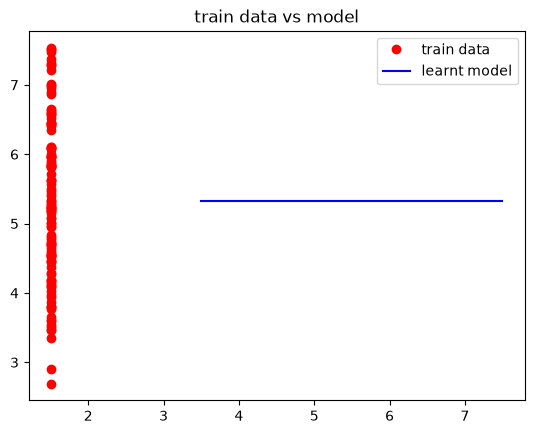

In [11]:
def ToolRegression(trainInput, testInput, trainOutput, testOutput):
    regressor = linear_model.LinearRegression()
    trainInput = np.array(trainInput)
    testInput = np.array(testInput)
    ndim = trainInput.ndim # variable number of dimensions (features)
    trainInput = trainInput.reshape(-1, ndim)# Change vector shape 1D (m, ) to 2D (m, n_features)
    testInput = testInput.reshape(-1, ndim)# Change vector shape 1D (m, ) to 2D (m, n_features)

    trainOutput = np.array(trainOutput)
    testOutput = np.array(testOutput)
    # fit(X, y) \
    # X shape (n_samples, n_features) and y shape (n_samples, )
    regressor.fit(trainInput, trainOutput)
    print("---Tool determined---")
    # predict(X) \
    # X shape (n_samples, n_features)
    computedOutput = regressor.predict(testInput)
    print(f"MAE: {mean_absolute_error(testOutput, computedOutput):.2f}")
    print(f"RMSE: {root_mean_squared_error(testOutput, computedOutput):.2f}")
    if ndim == 1:
        w0, w1 = regressor.intercept_, regressor.coef_[0]
        print(f'f(x, w) = {w0:.4f} + {w1:.4f}  * x')
        plotData(trainInput, trainOutput, testOutput, computedOutput, title='train data vs model')
    else:
        w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
        print(f'f(x, w) = {w0:.4f} + {w1:.4f}  * x1 + {w2:.4f}  * x2')

#inputData - 3 input traits: matrix[3][n_samples]
#outputData - 1 output trait: array[n_samples]
inputData, inputLabel, outputData, outputLabel = readCSV("data/v1_world-happiness-report-2017.csv", ['Family', 'Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score' )
trainInput, testInput, trainOutput, testOutput = splitData(inputData, inputLabel, outputData)

#inputData - 1st input trait (Family)
#outputData - 1 output trait (Happiness.Score)
# => univariate Regression: 124 ex train sample, 31 ex test sample
ToolRegression(trainInput[0], testInput[0], trainOutput, testOutput)
#univariateRegression(trainInput[0], trainOutput)

Reading file data/v3_world-happiness-report-2017.csv
f(x, w) = 2.035232987153294 + 2.7901913222858714  * x


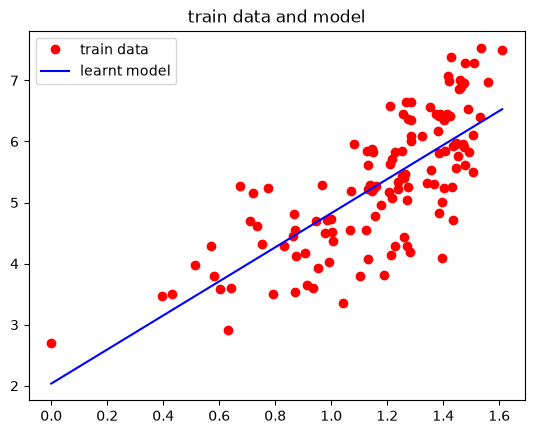

MAE:  0.7729381733039848
RMSE:  0.851742152665452


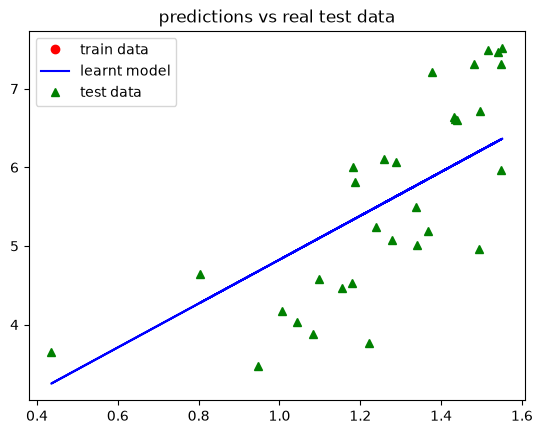

f(x,w) = 2.035232987153281 + 0 * x


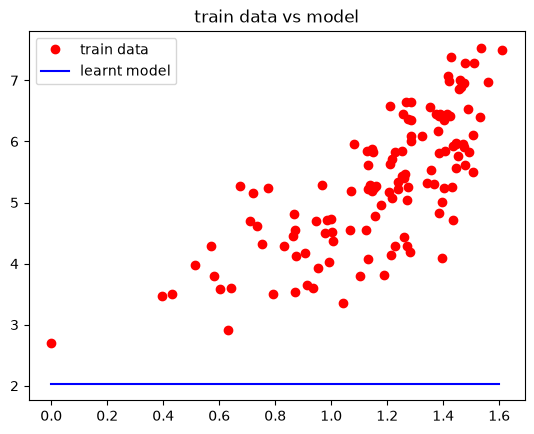

MAE: 0.7729381733039843
RMSE: 0.7254646946271763


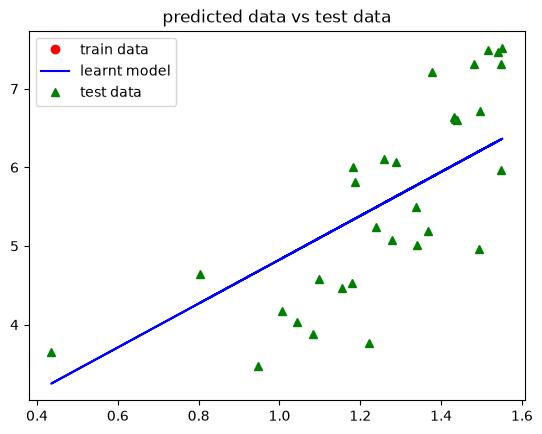

f(x, w) = 2.802791246984169 + 1.5188614637424371 * x1 + 2.7766272508066887 * x2
MAE:  0.6846507115678349
RMSE:  0.8203441230940248


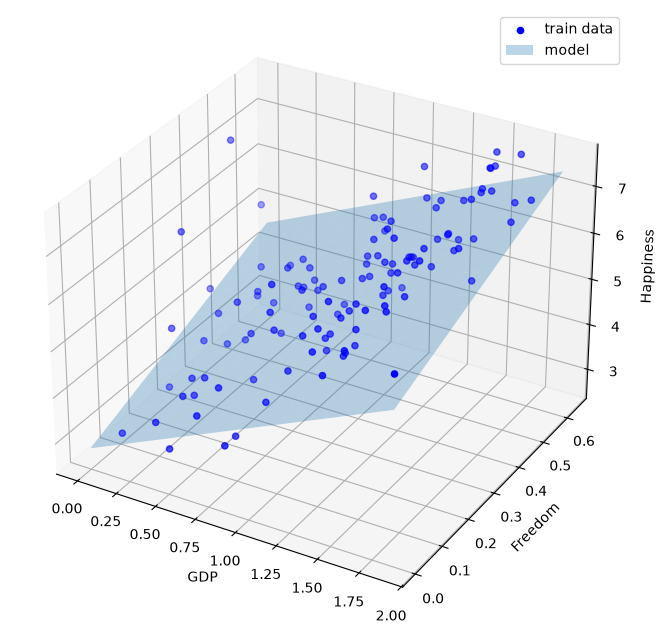

ValueError: shapes (124,2) and (124,1) not aligned: 2 (dim 1) != 124 (dim 0)

In [12]:
from pathlib import Path

path = Path('data')
file_paths = [str(p) for p in path.glob('*.csv')]

for p in file_paths:
    print("Reading file " + p)
    input1, inputLabel1, output1, outputLabel1 = readCSV(p, ['Family', 'Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')
    trainInput1, testInput1, trainOutput1, testOutput1 = splitData(input1, inputLabel1, output1)
    univariateRegression(trainInput1[0], testInput1[0], trainOutput1, testOutput1)
    myUnivariateRegression(trainInput1[0], testInput1[0], trainOutput1, testOutput1)
    multivariateRegression(trainInput1[1:], testInput1[1:], trainOutput1, testOutput1)
    myMultivariateRegression(trainInput1[1:], testInput1[1:], trainOutput1, testOutput1)

In [ ]:
inputData, inputLabel, outputData, outputLabel = readCSV('data/v1_world-happiness-report-2017.csv', ['Family', 'Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')
trainInput, testInput, trainOutput, testOutput = splitData(inputData, inputLabel, outputData)
myUnivariateRegression(trainInput[0], testInput[0], trainOutput, testOutput)
X_train = np.array([1, f, g] for f, g in zip(trainInput[0], trainInput[1]))
Y_train = np.array(trainOutput)
X_test = np.array([[1, f, g] for f,g in zip(testInput[0], testInput[1])])
X = []
for i in range(len(trainInput[0])):
    X.append([1, trainInput[0][i], trainInput[1][i]])
myMultivariateRegression(X, X_test, Y, testOutput)